#EDA Exploratory Data Analysis

1.import the files

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving EDA-DP.csv to EDA-DP.csv


2. Visualize files and conduct a preliminary data check.

In [ ]:
import pandas as pd
df=pd.read_csv("EDA-DP.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


3. get the basic info of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


4.1-4.3

Check the columns prone to dirty data to determine if cleaning is required.

In [ ]:
df['experience_level'].unique()

array(['SE', 'MI', 'EN', 'EX'], dtype=object)

In [ ]:
df['employment_type'].unique()

array(['FT', 'CT', 'PT', 'FL'], dtype=object)

In [ ]:
df['company_size'].unique()

array(['M', 'L', 'S'], dtype=object)

4.2. Approaches to Addressing Missing Data

Whenever a type of “dirty data” or issue is identified, strive to follow this process:

Identify + Explain + Plan

In [ ]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [ ]:
df = df.drop(columns=['CustomerID'])

In [ ]:
# example: Treat unreasonable ages as missing values and uniformly impute them later.
df.loc[(df['Age'] < 0) | (df['Age'] > 120), 'Age'] = np.nan

5. Perform frequency analysis on categorical variables (value_counts)

    Check whether the distribution is balanced

In [ ]:
df['experience_level'].value_counts()

,count
experience_level,
SE,10670
MI,4038
EN,1325
EX,501


In [ ]:
df['employment_type'].value_counts()

,count
employment_type,
FT,16454
PT,38
CT,28
FL,14


In [ ]:
df['company_size'].value_counts()

,count
company_size,
M,15306
L,1040
S,188


6. Create a chart based on the distribution (bar chart/pie chart/etc.)

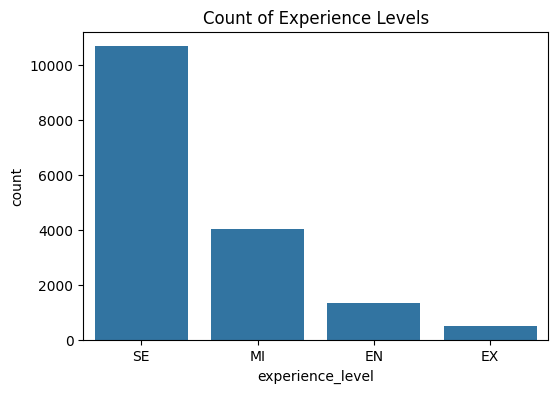

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='experience_level')#create a countplot by sns
plt.title("Count of Experience Levels")
plt.show()


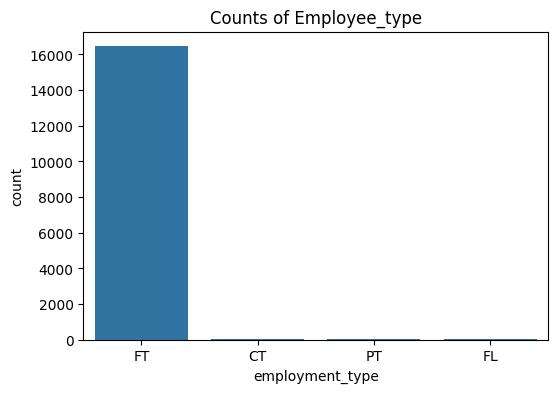

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='employment_type')
plt.title("Counts of Employee_type")
plt.show()

histpilot of the salary

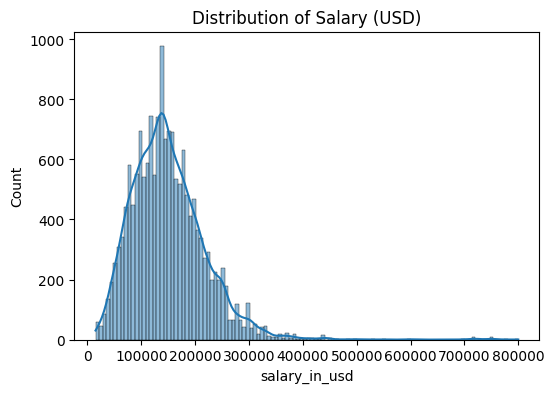

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='salary_in_usd', kde=True)
plt.title("Distribution of Salary (USD)")
plt.show()

salary vs experience_level boxplot



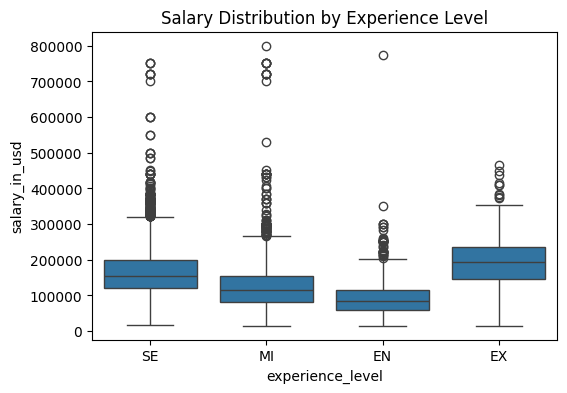

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd')
plt.title("Salary Distribution by Experience Level")
plt.show()

What does this box plot illustrate?

① Median salaries for the four experience levels show distinct differences
Observe the middle horizontal line (Median) in the box plot:

EX (Executive): Highest, approximately $180k–$200k

SE (Senior): Second highest, approximately $150k

MI (Mid-level): Moderate, approximately $120k

EN (Entry-level): Lowest, around 80k–90k

 Key takeaway: Higher experience correlates with higher pay.

② The range of salary distribution widens with increasing experience
Entry-level boxes are narrow (salaries are more concentrated)
Senior & Executive boxes are wide (salary variation increases)

 This indicates significant internal variation within high-experience tiers—some earn substantially more while others remain average—reflecting reality.

③ High-salary outliers primarily originate from SE, MI, and EX
Notice numerous upward-shooting dots:
The 300k–800k range almost exclusively comprises SE, MI, and EX
Entry-level high-salary outliers are rare

This demonstrates that high-paying positions predominantly come from more senior levels.

④ Data imbalance distorts the chart's shape

Because:

SE has 10,670 samples

EX has only 501 samples

EN has only 1,325 samples

➡ Resulting in:
SE showing the most outliers (due to large sample size)
EX appears to have a “high median,” but conclusions require caution due to its small sample size.

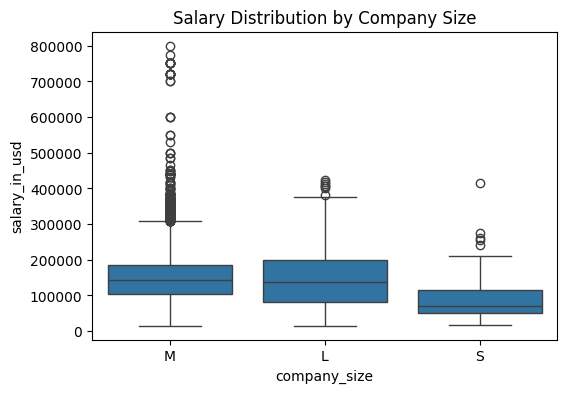

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='company_size', y='salary_in_usd')
plt.title("Salary Distribution by Company Size")
plt.show()

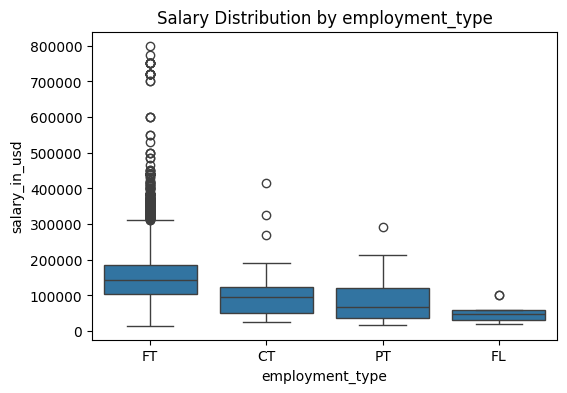

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='employment_type', y='salary_in_usd')
plt.title("Salary Distribution by employment_type")
plt.show()

In [ ]:
#overview
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# overview
df.shape
df.info()
df.describe()

# target distribution
df['target'].value_counts(normalize=True)

# missing values
df.isnull().sum()

# hist + box for a key feature
sns.histplot(df['mean radius'], kde=True)
sns.boxplot(x=df['mean radius'])

# feature vs target
sns.boxplot(x='target', y='mean radius', data=df)

# correlation
corr = df.drop(columns=['target']).corr()
sns.heatmap(corr)
